<a href="https://colab.research.google.com/github/rezailyaspratama26/rezaillyaspratama/blob/main/Analisis_Kinerja_Pemasaran_dan_Rekomendasi_KPI_Optimal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Muat data dari file CSV ke dalam DataFrame
df = pd.read_csv('/content/Marketing.csv')

# Tampilkan 5 baris pertama DataFrame untuk verifikasi
display(df.head())

,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


In [ ]:
# Tampilkan informasi ringkasan DataFrame
display(df.info())

# Tampilkan statistik deskriptif dari kolom numerik
display(df.describe())

# Tampilkan jumlah nilai unik di setiap kolom
display(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             308 non-null    int64  
 1   c_date         308 non-null    object 
 2   campaign_name  308 non-null    object 
 3   category       308 non-null    object 
 4   campaign_id    308 non-null    int64  
 5   impressions    308 non-null    int64  
 6   mark_spent     308 non-null    float64
 7   clicks         308 non-null    int64  
 8   leads          308 non-null    int64  
 9   orders         308 non-null    int64  
 10  revenue        308 non-null    float64
dtypes: float64(2), int64(6), object(3)
memory usage: 26.6+ KB


None

,id,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
count,308.000000,3.080000e+02,3.080000e+02,308.000000,308.000000,308.000000,308.000000,3.080000e+02
mean,154.500000,9.605628e+06,5.122475e+06,99321.038377,9739.996753,212.918831,26.113636,1.392512e+05
std,89.056162,2.543040e+07,2.631134e+07,144008.011181,12157.476244,300.459978,42.741288,2.763031e+05
min,1.000000,1.093400e+04,6.670000e+02,169.750000,20.000000,0.000000,0.000000,0.000000e+00
25%,77.750000,1.278230e+05,1.479568e+05,9465.195000,1347.250000,20.750000,3.000000,8.580000e+03
50%,154.500000,3.747540e+05,6.028100e+05,36765.150000,4349.500000,84.000000,9.000000,3.891700e+04
75%,231.250000,4.387490e+06,3.254450e+06,129372.250000,13499.250000,270.500000,29.250000,1.370492e+05
max,308.000000,8.945984e+07,4.199700e+08,880357.000000,61195.000000,1678.000000,369.000000,2.812520e+06


,0
id,308
c_date,28
campaign_name,11
category,4
campaign_id,11
impressions,301
mark_spent,308
clicks,274
leads,176
orders,88


In [ ]:
# Konversi kolom 'c_date' ke format datetime
df['c_date'] = pd.to_datetime(df['c_date'])

# Tampilkan nilai unik sebelum standardisasi untuk melihat inkonsistensi
print("Nilai unik 'campaign_name' sebelum standardisasi:")
display(df['campaign_name'].unique())
print("\nNilai unik 'category' sebelum standardisasi:")
display(df['category'].unique())

# Standardisasi kolom 'campaign_name' dan 'category' menjadi huruf kecil dan hapus spasi kosong
df['campaign_name'] = df['campaign_name'].str.lower().str.strip()
df['category'] = df['category'].str.lower().str.strip()

# Tampilkan nilai unik setelah standardisasi untuk verifikasi
print("\nNilai unik 'campaign_name' setelah standardisasi:")
display(df['campaign_name'].unique())
print("\nNilai unik 'category' setelah standardisasi:")
display(df['category'].unique())

Nilai unik 'campaign_name' sebelum standardisasi:


array(['facebook_tier1', 'facebOOK_tier2', 'google_hot', 'google_wide',
       'youtube_blogger', 'instagram_tier1', 'instagram_tier2',
       'facebook_retargeting', 'facebook_lal', 'instagram_blogger',
       'banner_partner'], dtype=object)


Nilai unik 'category' sebelum standardisasi:


array(['social', 'search', 'influencer', 'media'], dtype=object)


Nilai unik 'campaign_name' setelah standardisasi:


array(['facebook_tier1', 'facebook_tier2', 'google_hot', 'google_wide',
       'youtube_blogger', 'instagram_tier1', 'instagram_tier2',
       'facebook_retargeting', 'facebook_lal', 'instagram_blogger',
       'banner_partner'], dtype=object)


Nilai unik 'category' setelah standardisasi:


array(['social', 'search', 'influencer', 'media'], dtype=object)

Ringkasan Kinerja Berdasarkan Kategori:


,category,impressions,mark_spent,clicks,leads,orders,revenue,ctr,cpc,cr_clicks_leads,cr_leads_orders,cpl,cpo,romi
0,influencer,77800724,8305304.08,749973,16939,3014,21119887.0,0.963967,11.074137,2.258615,17.793258,490.306634,2755.575342,154.293964
1,media,1068337427,5026674.76,420003,10149,1566,6152960.0,0.039314,11.968188,2.416411,15.430092,495.287689,3209.881711,22.406169
2,search,72298252,3460400.07,330054,7107,828,3705065.0,0.456517,10.484345,2.153284,11.650485,486.900249,4179.227138,7.070423
3,social,359285996,13798500.91,1499889,31384,2635,11911454.0,0.417464,9.199681,2.092422,8.395998,439.666738,5236.622736,-13.675739



Ringkasan Kinerja Berdasarkan Nama Kampanye:


,campaign_name,impressions,mark_spent,clicks,leads,orders,revenue,ctr,cpc,cr_clicks_leads,cr_leads_orders,cpl,cpo,romi
0,banner_partner,1068337427,5026674.76,420003,10149,1566,6152960.0,0.039314,11.968188,2.416411,15.430092,495.287689,3209.881711,22.406169
1,facebook_lal,12697701,2641939.24,120012,1909,294,300233.0,0.945147,22.013959,1.590674,15.400733,1383.938837,8986.187891,-88.635886
2,facebook_retargeting,976685,266466.22,29954,506,108,536919.0,3.066905,8.895848,1.689257,21.343874,526.613083,2467.279815,101.496085
3,facebook_tier1,63044882,2564793.48,239997,3535,474,2396412.0,0.380676,10.686773,1.472935,13.408769,725.542710,5410.956709,-6.565109
4,facebook_tier2,69623161,4693870.97,329973,8428,688,3463306.0,0.473941,14.225015,2.554148,8.163265,556.937704,6822.486875,-26.216421
5,google_hot,4628993,1199998.76,90048,1833,281,2205747.0,1.945304,13.326212,2.035581,15.330060,654.663808,4270.458221,83.812440
6,google_wide,67669259,2260401.31,240006,5274,547,1499318.0,0.354675,9.418103,2.197445,10.371634,428.593347,4132.360713,-33.670274
7,instagram_blogger,34112411,4247367.57,299959,7008,1100,5808454.0,0.879325,14.159827,2.336319,15.696347,606.074140,3861.243245,36.754211
8,instagram_tier1,75136799,2565277.25,269961,6632,758,4544124.0,0.359293,9.502399,2.456651,11.429433,386.802963,3384.270778,77.139683
9,instagram_tier2,137806768,1066153.75,509992,10374,313,670460.0,0.370078,2.090530,2.034150,3.017158,102.771713,3406.242013,-37.114136


/tmp/ipython-input-19-3092680524.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='romi', y='category', data=category_summary.sort_values('romi', ascending=False), ax=axes[0, 0], palette='viridis')
/tmp/ipython-input-19-3092680524.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cpo', y='category', data=category_summary.sort_values('cpo', ascending=True), ax=axes[0, 1], palette='viridis')
/tmp/ipython-input-19-3092680524.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cpl', y='category', data=category_summary.sort_values

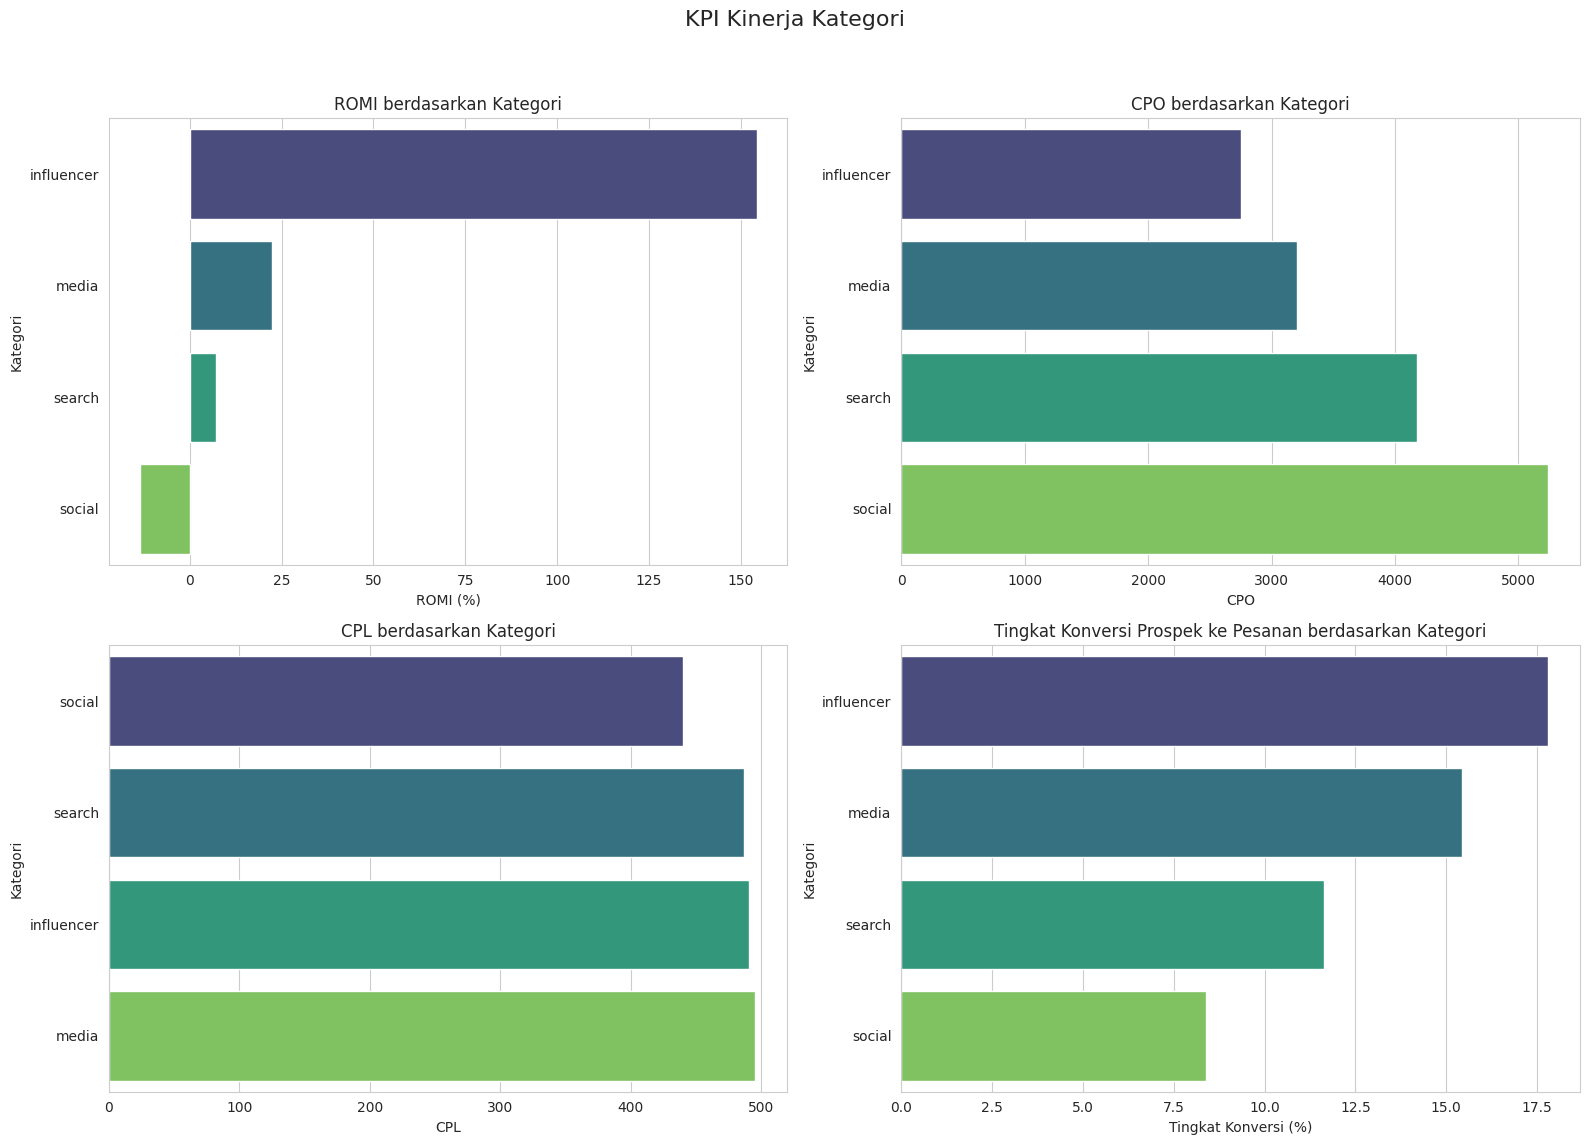

/tmp/ipython-input-19-3092680524.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='romi', y='campaign_name', data=top_romi_campaigns, ax=axes[0, 0], palette='viridis')
/tmp/ipython-input-19-3092680524.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='romi', y='campaign_name', data=bottom_romi_campaigns, ax=axes[0, 1], palette='viridis')
/tmp/ipython-input-19-3092680524.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cpo', y='campaign_name', data=top_romi_campaigns.sort_values('cpo', ascending=True), ax=axes[1, 0], pale

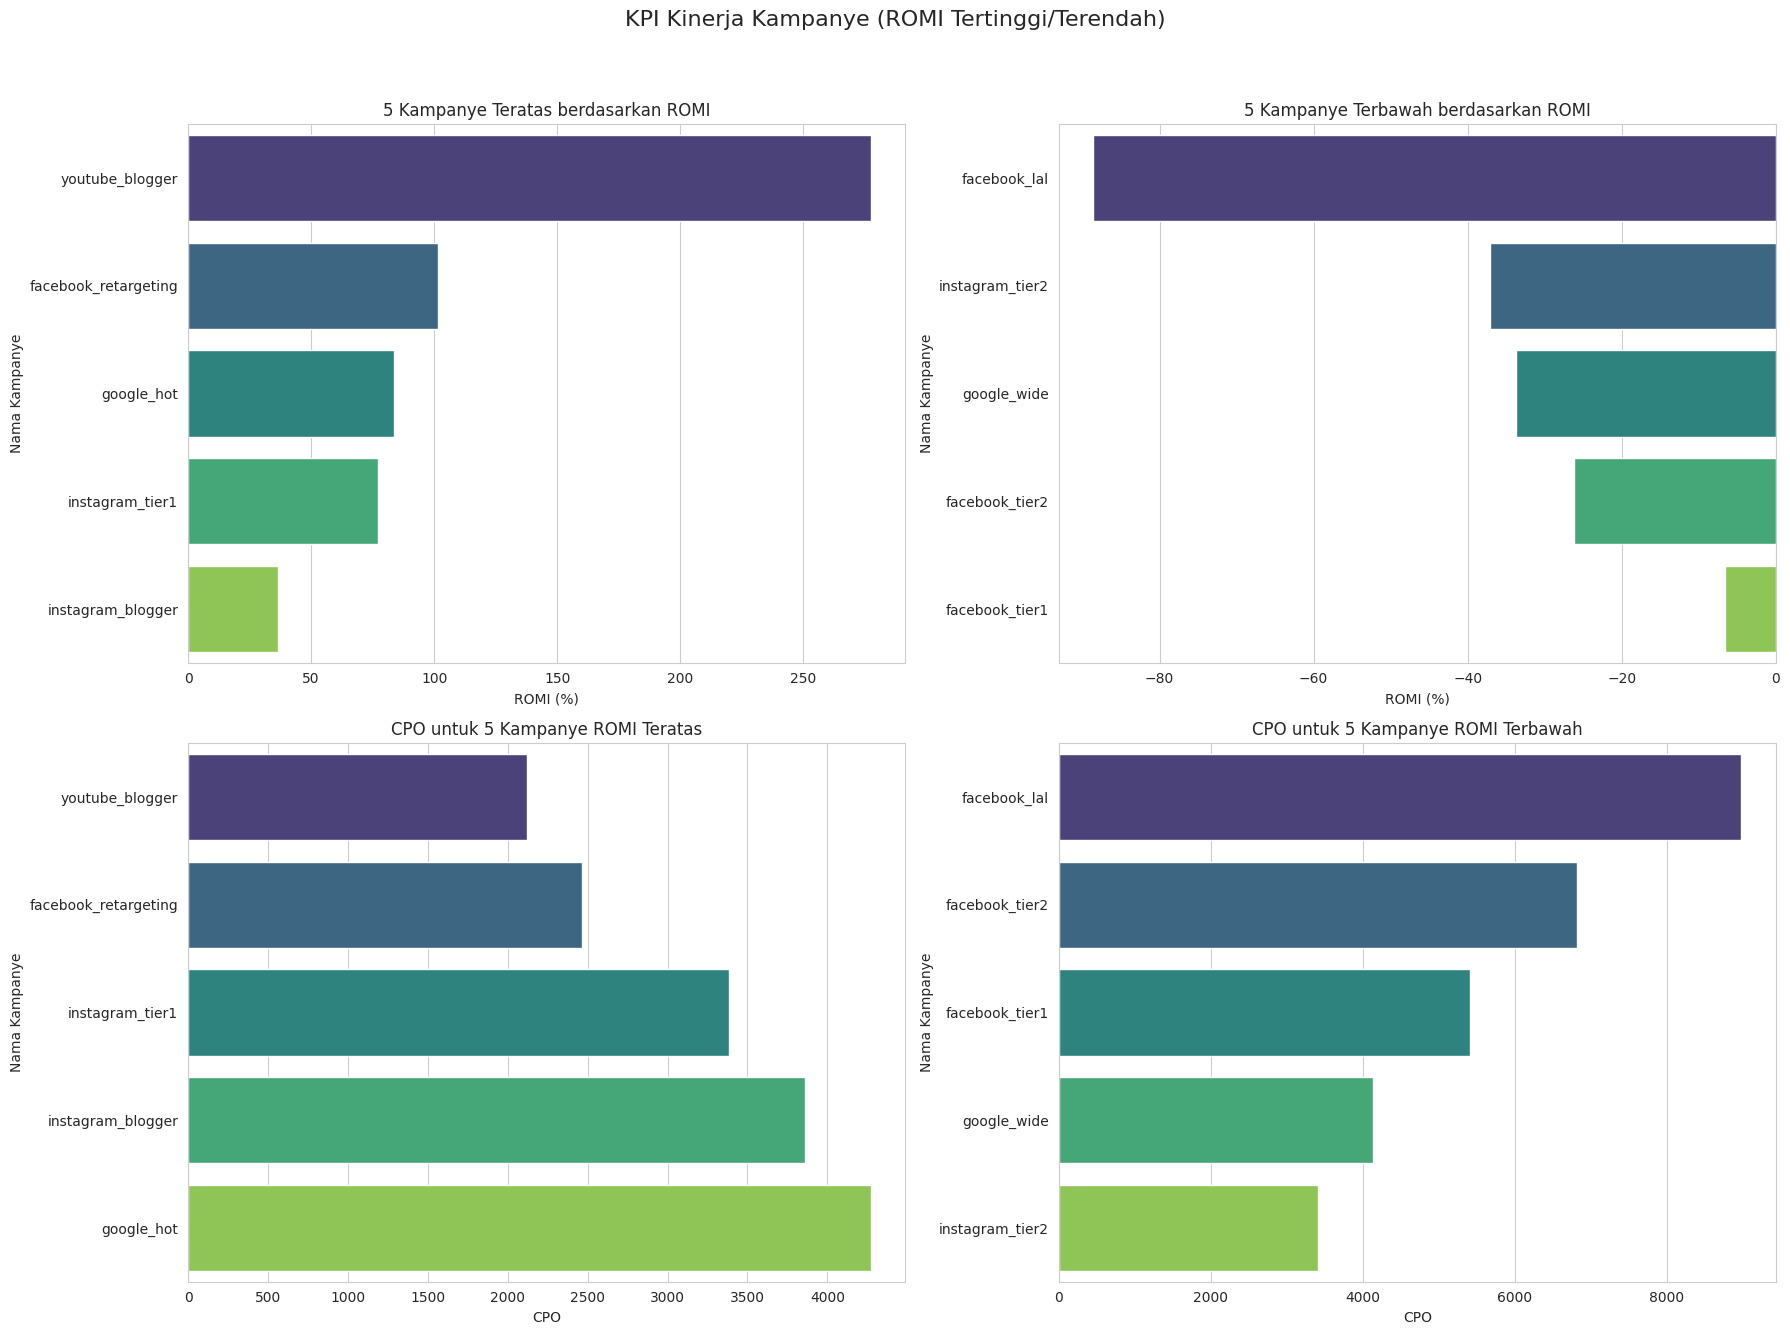

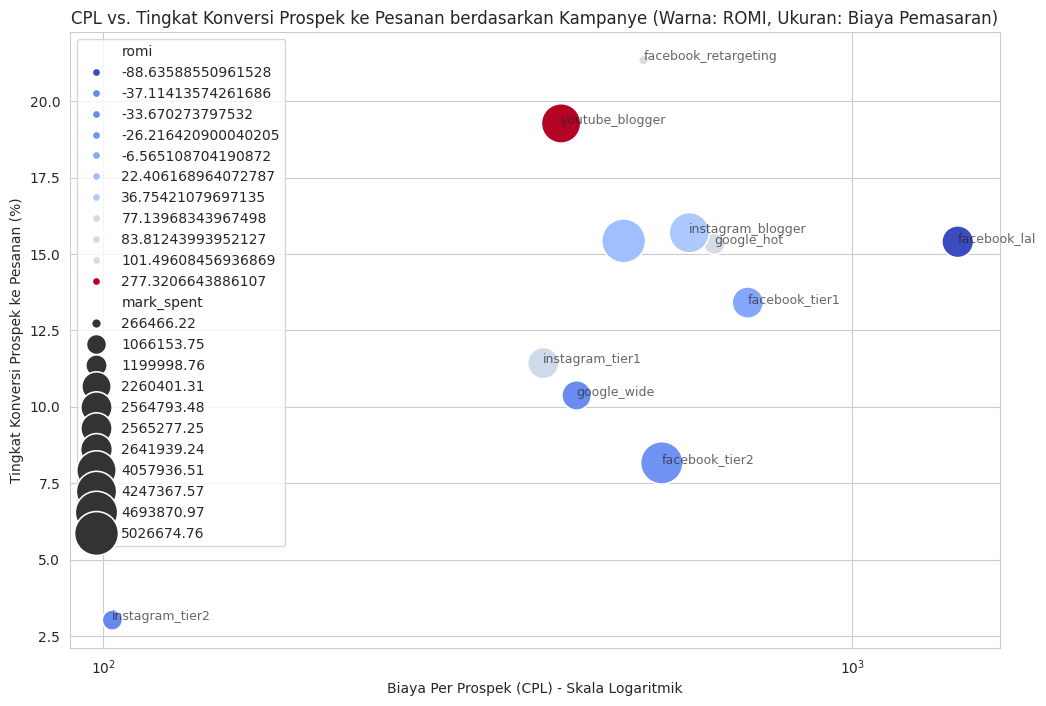

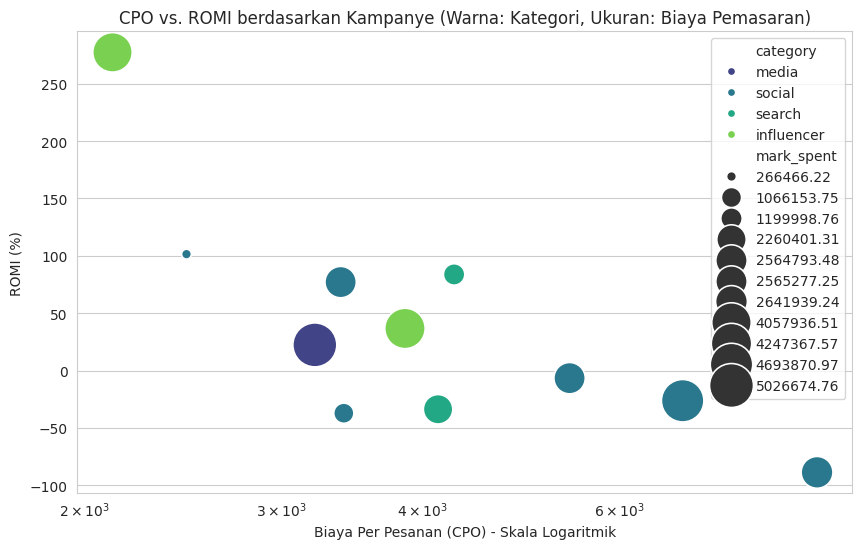

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung metrik agregat untuk setiap kategori
category_summary = df.groupby('category').agg({
    'impressions': 'sum',
    'mark_spent': 'sum',
    'clicks': 'sum',
    'leads': 'sum',
    'orders': 'sum',
    'revenue': 'sum'
}).reset_index()

# Hitung KPI untuk setiap kategori
category_summary['ctr'] = (category_summary['clicks'] / category_summary['impressions']) * 100
category_summary['cpc'] = category_summary['mark_spent'] / category_summary['clicks']
category_summary['cr_clicks_leads'] = (category_summary['leads'] / category_summary['clicks']) * 100
category_summary['cr_leads_orders'] = (category_summary['orders'] / category_summary['leads']) * 100
category_summary['cpl'] = category_summary['mark_spent'] / category_summary['leads']
category_summary['cpo'] = category_summary['mark_spent'] / category_summary['orders']
category_summary['romi'] = ((category_summary['revenue'] - category_summary['mark_spent']) / category_summary['mark_spent']) * 100

# Hitung metrik agregat untuk setiap nama kampanye
campaign_summary = df.groupby('campaign_name').agg({
    'impressions': 'sum',
    'mark_spent': 'sum',
    'clicks': 'sum',
    'leads': 'sum',
    'orders': 'sum',
    'revenue': 'sum'
}).reset_index()

# Hitung KPI untuk setiap kampanye
campaign_summary['ctr'] = (campaign_summary['clicks'] / campaign_summary['impressions']) * 100
campaign_summary['cpc'] = campaign_summary['mark_spent'] / campaign_summary['clicks']
campaign_summary['cr_clicks_leads'] = (campaign_summary['leads'] / campaign_summary['clicks']) * 100
campaign_summary['cr_leads_orders'] = (campaign_summary['orders'] / campaign_summary['leads']) * 100
campaign_summary['cpl'] = campaign_summary['mark_spent'] / campaign_summary['leads']
campaign_summary['cpo'] = campaign_summary['mark_spent'] / campaign_summary['orders']
campaign_summary['romi'] = ((campaign_summary['revenue'] - campaign_summary['mark_spent']) / campaign_summary['mark_spent']) * 100

# Menangani nilai tak terhingga (inf) dan NaN yang mungkin muncul dari pembagian dengan nol
import numpy as np
category_summary.replace([np.inf, -np.inf], np.nan, inplace=True)
campaign_summary.replace([np.inf, -np.inf], np.nan, inplace=True)

# Mengisi nilai NaN dengan 0 (atau nilai lain yang masuk akal tergantung konteks bisnis)
# Dalam kasus metrik kinerja, NaN sering kali berarti tidak ada data konversi, jadi 0 mungkin sesuai.
category_summary.fillna(0, inplace=True)
campaign_summary.fillna(0, inplace=True)


print("Ringkasan Kinerja Berdasarkan Kategori:")
display(category_summary)

print("\nRingkasan Kinerja Berdasarkan Nama Kampanye:")
display(campaign_summary)

# Visualisasi

# Atur gaya plot
sns.set_style("whitegrid")

# Plotting KPI Kategori
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('KPI Kinerja Kategori', fontsize=16)

# Bar plot ROMI berdasarkan Kategori
sns.barplot(x='romi', y='category', data=category_summary.sort_values('romi', ascending=False), ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('ROMI berdasarkan Kategori')
axes[0, 0].set_xlabel('ROMI (%)')
axes[0, 0].set_ylabel('Kategori')

# Bar plot CPO berdasarkan Kategori
sns.barplot(x='cpo', y='category', data=category_summary.sort_values('cpo', ascending=True), ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('CPO berdasarkan Kategori')
axes[0, 1].set_xlabel('CPO')
axes[0, 1].set_ylabel('Kategori')

# Bar plot CPL berdasarkan Kategori
sns.barplot(x='cpl', y='category', data=category_summary.sort_values('cpl', ascending=True), ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('CPL berdasarkan Kategori')
axes[1, 0].set_xlabel('CPL')
axes[1, 0].set_ylabel('Kategori')

# Bar plot Tingkat Konversi Prospek ke Pesanan berdasarkan Kategori
sns.barplot(x='cr_leads_orders', y='category', data=category_summary.sort_values('cr_leads_orders', ascending=False), ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Tingkat Konversi Prospek ke Pesanan berdasarkan Kategori')
axes[1, 1].set_xlabel('Tingkat Konversi (%)')
axes[1, 1].set_ylabel('Kategori')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Sesuaikan layout agar judul tidak terpotong
plt.show()


# Plotting KPI Kampanye - Fokus pada metrik kunci dan profitabilitas
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('KPI Kinerja Kampanye (ROMI Tertinggi/Terendah)', fontsize=16)

# 5 Kampanye dengan ROMI Tertinggi
top_romi_campaigns = campaign_summary.sort_values('romi', ascending=False).head(5)
sns.barplot(x='romi', y='campaign_name', data=top_romi_campaigns, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('5 Kampanye Teratas berdasarkan ROMI')
axes[0, 0].set_xlabel('ROMI (%)')
axes[0, 0].set_ylabel('Nama Kampanye')

# 5 Kampanye dengan ROMI Terendah
bottom_romi_campaigns = campaign_summary.sort_values('romi', ascending=True).head(5)
sns.barplot(x='romi', y='campaign_name', data=bottom_romi_campaigns, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('5 Kampanye Terbawah berdasarkan ROMI')
axes[0, 1].set_xlabel('ROMI (%)')
axes[0, 1].set_ylabel('Nama Kampanye')

# CPO untuk Kampanye ROMI Tertinggi/Terendah
sns.barplot(x='cpo', y='campaign_name', data=top_romi_campaigns.sort_values('cpo', ascending=True), ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('CPO untuk 5 Kampanye ROMI Teratas')
axes[1, 0].set_xlabel('CPO')
axes[1, 0].set_ylabel('Nama Kampanye')

sns.barplot(x='cpo', y='campaign_name', data=bottom_romi_campaigns.sort_values('cpo', ascending=False), ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('CPO untuk 5 Kampanye ROMI Terbawah')
axes[1, 1].set_xlabel('CPO')
axes[1, 1].set_ylabel('Nama Kampanye')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Gabungkan campaign_summary dengan df untuk mendapatkan informasi kategori
campaign_summary_with_category = campaign_summary.merge(df[['campaign_name', 'category']].drop_duplicates(), on='campaign_name', how='left')

# Scatter plot: CPL vs. Tingkat Konversi Prospek ke Pesanan dengan ROMI sebagai warna dan Mark Spent sebagai ukuran
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x='cpl', y='cr_leads_orders', hue='romi', size='mark_spent', sizes=(50, 1000), data=campaign_summary_with_category, palette='coolwarm', legend='full')
plt.title('CPL vs. Tingkat Konversi Prospek ke Pesanan berdasarkan Kampanye (Warna: ROMI, Ukuran: Biaya Pemasaran)')
plt.xlabel('Biaya Per Prospek (CPL) - Skala Logaritmik')
plt.ylabel('Tingkat Konversi Prospek ke Pesanan (%)')
plt.xscale('log') # Gunakan skala logaritmik untuk CPL karena rentang nilainya lebar
plt.grid(True)

# Tambahkan anotasi untuk kampanye dengan ROMI tertinggi dan terendah
for i in range(len(campaign_summary_with_category)):
    if campaign_summary_with_category.loc[i, 'campaign_name'] in top_romi_campaigns['campaign_name'].tolist() or \
       campaign_summary_with_category.loc[i, 'campaign_name'] in bottom_romi_campaigns['campaign_name'].tolist():
        plt.text(campaign_summary_with_category.loc[i, 'cpl'], campaign_summary_with_category.loc[i, 'cr_leads_orders'],
                 campaign_summary_with_category.loc[i, 'campaign_name'], fontsize=9, alpha=0.7)

plt.show()

# Scatter plot: CPO vs. ROMI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cpo', y='romi', hue='category', size='mark_spent', sizes=(50, 1000), data=campaign_summary_with_category, palette='viridis', legend='full')
plt.title('CPO vs. ROMI berdasarkan Kampanye (Warna: Kategori, Ukuran: Biaya Pemasaran)')
plt.xlabel('Biaya Per Pesanan (CPO) - Skala Logaritmik')
plt.ylabel('ROMI (%)')
plt.xscale('log') # Gunakan skala logaritmik untuk CPO
plt.grid(True)
plt.show()

In [ ]:
# KPI Potensial dan relevansinya berdasarkan analisis:
potential_kpis = {
    'impressions': 'Relevansi: Mengukur kesadaran merek (brand awareness) dan potensi jangkauan audiens kampanye.',
    'mark_spent': 'Relevansi: Menunjukkan total biaya investasi pemasaran yang dikeluarkan.',
    'clicks': 'Relevansi: Mengukur tingkat interaksi awal audiens dengan materi iklan dan seberapa menarik pesan tersebut.',
    'leads': 'Relevansi: Mengukur efektivitas kampanye dalam menghasilkan prospek atau calon pelanggan yang tertarik.',
    'orders': 'Relevansi: Mengukur jumlah konversi langsung (penjualan) yang dihasilkan oleh kampanye pemasaran.',
    'revenue': 'Relevansi: Mengukur total pendapatan kotor yang diatribusikan langsung ke kampanye pemasaran.',
    'ctr': 'Relevansi: Mengukur efektivitas materi iklan, penargetan, dan penempatan iklan dalam mendorong klik dari tayangan.',
    'cpc': 'Relevansi: Mengukur efisiensi biaya untuk mengarahkan lalu lintas (klik) ke aset web (misalnya, landing page).',
    'cr_clicks_leads': 'Relevansi: Mengukur efektivitas halaman tujuan, formulir, dan tawaran dalam mengubah pengunjung (dari klik) menjadi prospek.',
    'cr_leads_orders': 'Relevansi: Mengukur efektivitas proses penjualan atau tim nurturing dalam mengubah prospek menjadi pelanggan berbayar (pesanan).',
    'cpl': 'Relevansi: Mengukur efisiensi biaya dalam memperoleh setiap prospek baru.',
    'cpo': 'Relevansi: Mengukur efisiensi biaya dalam memperoleh setiap pesanan atau pelanggan baru.',
    'romi': 'Relevansi: Mengukur profitabilitas bersih dari investasi pemasaran, menunjukkan seberapa banyak keuntungan yang dihasilkan untuk setiap unit mata uang yang diinvestasikan.'
}

print("Indikator Kinerja Utama (KPI) Potensial dan Relevansinya:")
for kpi, relevance in potential_kpis.items():
    print(f"- **{kpi.upper()}**: {relevance}")

print("\nBerdasarkan analisis dan visualisasi:")
print("- Untuk tujuan yang berfokus pada profitabilitas dan pertumbuhan penjualan, KPI seperti ROMI, CPO, dan CR_leads_orders sangat relevan.")
print("- CPL penting untuk efisiensi perolehan prospek, tetapi kualitas prospek (yang tercermin dalam CR_leads_orders) juga krusial.")
print("- CTR dan CPC lebih relevan untuk mengukur efektivitas dan efisiensi di bagian atas funnel (awareness dan engagement awal).")

Indikator Kinerja Utama (KPI) Potensial dan Relevansinya:
- **IMPRESSIONS**: Relevansi: Mengukur kesadaran merek (brand awareness) dan potensi jangkauan audiens kampanye.
- **MARK_SPENT**: Relevansi: Menunjukkan total biaya investasi pemasaran yang dikeluarkan.
- **CLICKS**: Relevansi: Mengukur tingkat interaksi awal audiens dengan materi iklan dan seberapa menarik pesan tersebut.
- **LEADS**: Relevansi: Mengukur efektivitas kampanye dalam menghasilkan prospek atau calon pelanggan yang tertarik.
- **ORDERS**: Relevansi: Mengukur jumlah konversi langsung (penjualan) yang dihasilkan oleh kampanye pemasaran.
- **REVENUE**: Relevansi: Mengukur total pendapatan kotor yang diatribusikan langsung ke kampanye pemasaran.
- **CTR**: Relevansi: Mengukur efektivitas materi iklan, penargetan, dan penempatan iklan dalam mendorong klik dari tayangan.
- **CPC**: Relevansi: Mengukur efisiensi biaya untuk mengarahkan lalu lintas (klik) ke aset web (misalnya, landing page).
- **CR_CLICKS_LEADS**: Relevan

In [ ]:
print("--- Interpretasi Hasil Analisis dan Rekomendasi KPI Optimal ---")

print("\nAnalisis Kinerja Kategori:")
print("- Berdasarkan ROMI, kategori 'influencer' menunjukkan profitabilitas tertinggi (ROMI > 100%), diikuti oleh 'media'.")
print("- Kategori 'search' memiliki ROMI positif namun lebih rendah, sementara 'social' memiliki ROMI negatif, menandakan kategori ini belum menghasilkan keuntungan dari biaya pemasaran yang dikeluarkan.")
print("- Dalam hal efisiensi biaya per pesanan (CPO), 'influencer' adalah yang paling efisien, diikuti oleh 'media'.")
print("- Untuk biaya per prospek (CPL), 'social' adalah yang paling murah, namun tingkat konversi prospek ke pesanan (CR_leads_orders) juga yang terendah.")
print("- Kategori 'influencer' memiliki tingkat konversi prospek ke pesanan tertinggi.")

print("\nAnalisis Kinerja Kampanye Individual:")
print("- Kampanye 'youtube_blogger' (di bawah kategori 'influencer') adalah kampanye paling menguntungkan dengan ROMI tertinggi.")
print("- 'facebook_retargeting' juga menunjukkan ROMI yang sangat baik dan tingkat konversi prospek ke pesanan yang tinggi.")
print("- Beberapa kampanye menunjukkan ROMI negatif, termasuk kampanye 'facebook_lal', 'facebook_tier1', 'facebook_tier2', 'google_wide', dan 'instagram_tier2'.")
print("- Kampanye 'instagram_tier2' memiliki CPL yang sangat rendah tetapi ROMI yang paling negatif dan tingkat konversi prospek ke pesanan yang sangat rendah. Ini mengindikasikan meskipun biaya perolehan prospek murah, prospek dari kampanye ini mungkin berkualitas rendah atau proses konversinya tidak efektif.")
print("- 'youtube_blogger' adalah kampanye yang paling efisien dalam menghasilkan pesanan (CPO terendah).")

print("\nTrade-offs Antar KPI (Dari Scatter Plot):")
print("- Terlihat jelas trade-off antara CPL (Biaya Per Prospek) dan profitabilitas (ROMI) atau efisiensi per pesanan (CPO). Kampanye dengan CPL sangat rendah ('instagram_tier2') memiliki ROMI dan CR_leads_orders yang buruk.")
print("- Sebaliknya, kampanye dengan ROMI dan CPO yang baik ('youtube_blogger', 'facebook_retargeting') mungkin memiliki CPL yang sedikit lebih tinggi, tetapi prospek yang dihasilkan tampaknya berkualitas lebih baik dan lebih mungkin berkonversi menjadi pesanan.")
print("- Scatter plot CPO vs. ROMI menunjukkan klaster kampanye berdasarkan kategori, menegaskan bahwa kinerja profitabilitas dan efisiensi per pesanan sangat dipengaruhi oleh kategori pemasaran.")

print("\nRekomendasi KPI Optimal Berdasarkan Tujuan (Diasumsikan: Maksimalisasi Profitabilitas dan Penjualan):")
print("Berdasarkan analisis mendalam, KPI yang paling optimal untuk difokuskan guna mengukur keberhasilan dan mendorong profitabilitas serta penjualan adalah:")
print("- **ROMI (Return on Marketing Investment)**: Ini adalah metrik profitabilitas paling penting. ROMI secara langsung mengukur pengembalian finansial dari setiap rupiah yang diinvestasikan dalam pemasaran.")
print("- **CPO (Cost Per Order)**: Mengukur efisiensi biaya dalam mengakuisisi pelanggan berbayar. Menurunkan CPO berarti mendapatkan penjualan dengan biaya yang lebih rendah.")
print("- **CR_leads_orders (Lead-to-Order Conversion Rate)**: Menunjukkan seberapa efektif prospek diubah menjadi pelanggan. Metrik ini mengindikasikan kualitas prospek dan efektivitas proses konversi (baik dari sisi pemasaran maupun penjualan).")

print("\nKPI Sekunder yang Penting untuk Dipantau:")
print("- **CPL (Cost Per Lead)**: Meskipun bukan metrik profitabilitas akhir, CPL penting untuk mengelola biaya di bagian atas funnel dan memastikan bahwa proses akuisisi prospek efisien. Namun, CPL harus selalu dipertimbangkan dalam konteks kualitas prospek (CR_leads_orders) dan kontribusinya terhadap profitabilitas keseluruhan (ROMI).")
print("- **Revenue dan Orders**: Ini adalah metrik dasar yang mengukur volume penjualan. Meskipun tidak menunjukkan efisiensi atau profitabilitas secara langsung seperti CPO atau ROMI, mereka tetap penting untuk dipantau sebagai indikator kinerja bisnis secara keseluruhan.")
print("- **CTR dan CR_clicks_leads**: Berguna untuk mengoptimalkan tahap awal funnel pemasaran (kesadaran, interaksi, perolehan prospek awal).")


print("\nJustifikasi Rekomendasi:")
print("Memilih ROMI, CPO, dan CR_leads_orders sebagai KPI utama secara langsung selaras dengan tujuan bisnis untuk meningkatkan profitabilitas dan penjualan. ROMI memberikan pandangan menyeluruh tentang efektivitas investasi, CPO fokus pada biaya akuisisi pelanggan yang sebenarnya, dan CR_leads_orders menilai kualitas prospek dan efektivitas proses konversi. Sementara metrik lain memberikan wawasan tentang aspek-aspek tertentu dari funnel pemasaran, ketiganya memberikan gambaran paling langsung tentang dampak pemasaran terhadap laba bersih perusahaan. Mengoptimalkan ketiga KPI ini akan berkontribusi paling signifikan terhadap kesuksesan bisnis.")

--- Interpretasi Hasil Analisis dan Rekomendasi KPI Optimal ---

Analisis Kinerja Kategori:
- Berdasarkan ROMI, kategori 'influencer' menunjukkan profitabilitas tertinggi (ROMI > 100%), diikuti oleh 'media'.
- Kategori 'search' memiliki ROMI positif namun lebih rendah, sementara 'social' memiliki ROMI negatif, menandakan kategori ini belum menghasilkan keuntungan dari biaya pemasaran yang dikeluarkan.
- Dalam hal efisiensi biaya per pesanan (CPO), 'influencer' adalah yang paling efisien, diikuti oleh 'media'.
- Untuk biaya per prospek (CPL), 'social' adalah yang paling murah, namun tingkat konversi prospek ke pesanan (CR_leads_orders) juga yang terendah.
- Kategori 'influencer' memiliki tingkat konversi prospek ke pesanan tertinggi.

Analisis Kinerja Kampanye Individual:
- Kampanye 'youtube_blogger' (di bawah kategori 'influencer') adalah kampanye paling menguntungkan dengan ROMI tertinggi.
- 'facebook_retargeting' juga menunjukkan ROMI yang sangat baik dan tingkat konversi prospek ke 